# 0. Config and setup

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from collections import Counter
import random, time

# Config
DATA_ROOT = Path("data/cityscapes-depth-and-segmentation/data")
SPLITS = ["train", "val"]
MODALITIES = ["image", "depth", "label"]

CITYSCAPES_CLASSES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain", "sky",
    "person", "rider", "car", "truck", "bus", "train", "motorcycle", "bicycle",
]
N_CLASSES = len(CITYSCAPES_CLASSES)
VOID_LABEL = -1

np.random.seed(42)
random.seed(42)


def load(split, modality, idx):
    return np.load(DATA_ROOT / split / modality / f"{idx}.npy")

# 1. Basic data check

In [49]:
print("=" * 70)
print("1. BASIC INVENTORY & FILE-PAIRING CHECK")
print("=" * 70)

split_ids = {}
file_counts = {}
for s in SPLITS:
    ids_per_mod = {}
    for m in MODALITIES:
        d = DATA_ROOT / s / m
        ids_per_mod[m] = set(int(p.stem) for p in d.glob("*.npy"))
        file_counts[(s, m)] = len(ids_per_mod[m])
    # Check all modalities have same IDs
    common = ids_per_mod["image"] & ids_per_mod["depth"] & ids_per_mod["label"]
    only_img = ids_per_mod["image"] - common
    only_dep = ids_per_mod["depth"] - common
    only_lbl = ids_per_mod["label"] - common
    split_ids[s] = sorted(common)

    print(f"\n  [{s}]")
    for m in MODALITIES:
        print(f"  {m}: {file_counts[(s, m)]} files")
    print(f"  Matched triplets: {len(common)}")
    if only_img or only_dep or only_lbl:
        print(f"  WARNING Unmatched -- image-only: {only_img}, depth-only: {only_dep}, label-only: {only_lbl}")
    else:
        print(f"  OK -- All files perfectly paired across modalities")

# Shape / dtype consistency check on ALL samples
print("\n  Shape / dtype consistency (all samples):")
shape_dtype = {m: Counter() for m in MODALITIES}
for s in SPLITS:
    for sid in split_ids[s]:
        for m in MODALITIES:
            arr = load(s, m, sid)
            shape_dtype[m][(arr.shape, str(arr.dtype))] += 1

all_consistent = True
for m in MODALITIES:
    items = shape_dtype[m].most_common()
    if len(items) == 1:
        shape, dtype = items[0][0]
        print(f"    {m:6s}: shape={str(shape):20s}  dtype={dtype}  (all consistent)")
    else:
        all_consistent = False
        print(f"    {m:6s}: INCONSISTENT shapes/dtypes:")
        for (shape, dtype), cnt in items:
            print(f"            shape={shape}  dtype={dtype}  count={cnt}")

1. BASIC INVENTORY & FILE-PAIRING CHECK

  [train]
  image: 2975 files
  depth: 2975 files
  label: 2975 files
  Matched triplets: 2975
  OK -- All files perfectly paired across modalities

  [val]
  image: 500 files
  depth: 500 files
  label: 500 files
  Matched triplets: 500
  OK -- All files perfectly paired across modalities

  Shape / dtype consistency (all samples):
    image : shape=(128, 256, 3)         dtype=float64  (all consistent)
    depth : shape=(128, 256, 1)         dtype=float64  (all consistent)
    label : shape=(128, 256)            dtype=float64  (all consistent)


# 2. Visual examples


2. VISUAL EXAMPLES


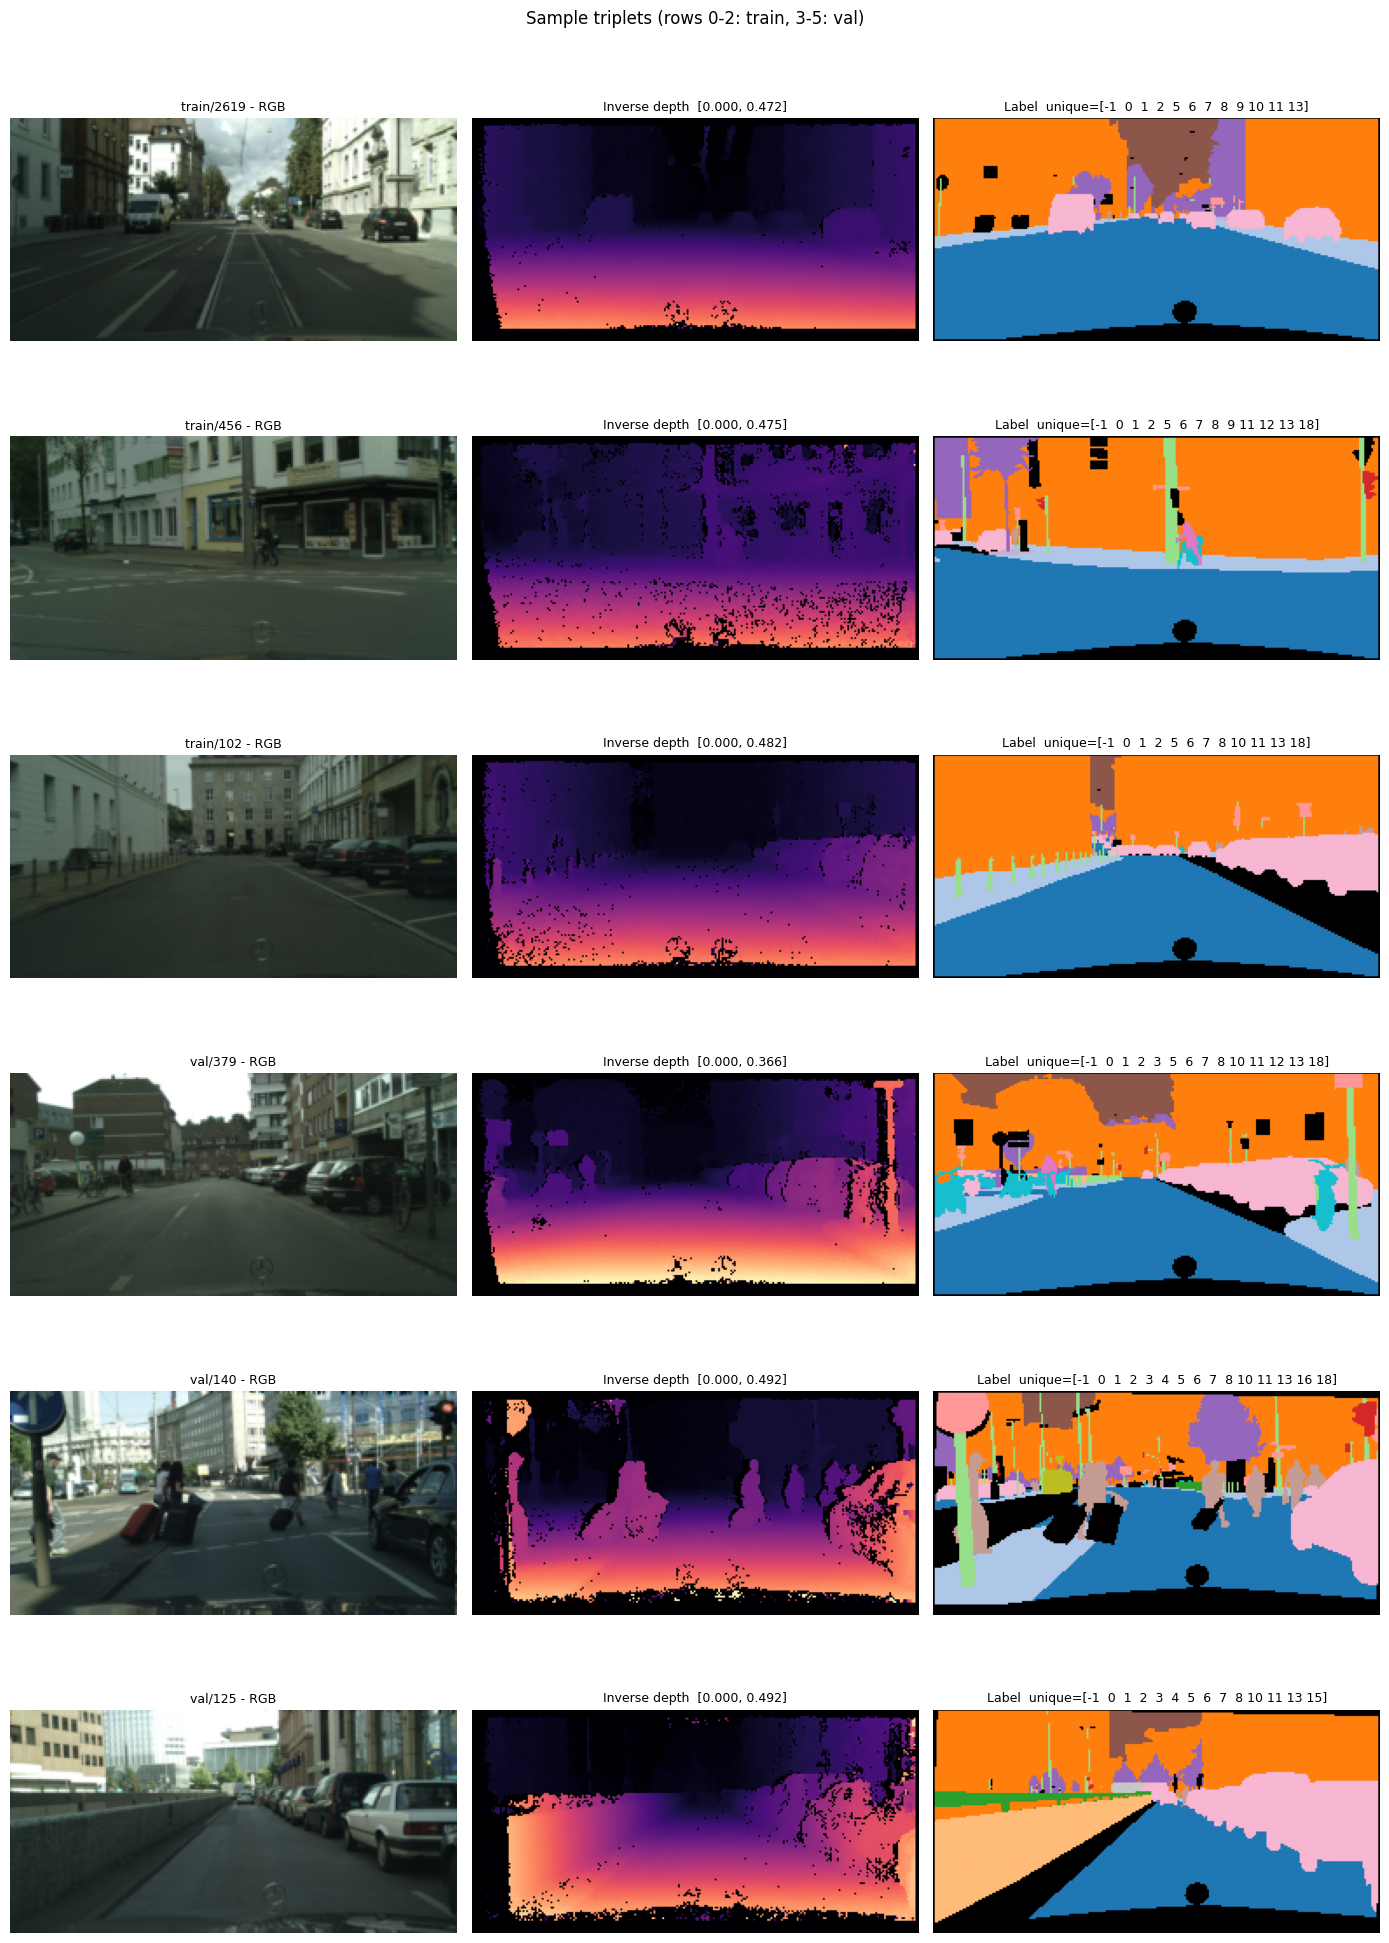

In [50]:
print("\n" + "=" * 70)
print("2. VISUAL EXAMPLES")
print("=" * 70)

cmap_seg = plt.colormaps.get_cmap("tab20")
CLASS_COLORS = np.array([cmap_seg(i)[:3] for i in range(N_CLASSES)])


def label_to_rgb(lbl_arr):
    lbl = lbl_arr.squeeze().astype(int)
    rgb = np.zeros((*lbl.shape, 3))
    for c in range(N_CLASSES):
        rgb[lbl == c] = CLASS_COLORS[c]
    # void pixels - black
    rgb[lbl == VOID_LABEL] = [0, 0, 0]
    return rgb


sample_train = random.sample(split_ids["train"], 3)
sample_val = random.sample(split_ids["val"], 3)

fig, axes = plt.subplots(6, 3, figsize=(14, 20))
for row, (split, sid) in enumerate(
    [(s, i) for s in ["train", "val"] for i in (sample_train if s == "train" else sample_val)]
):
    img = load(split, "image", sid).squeeze()
    dep = load(split, "depth", sid).squeeze()
    lbl = load(split, "label", sid)

    lbl_rgb = label_to_rgb(lbl)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{split}/{sid} - RGB", fontsize=9)
    axes[row, 1].imshow(dep, cmap="magma")
    axes[row, 1].set_title(f"Inverse depth  [{dep.min():.3f}, {dep.max():.3f}]", fontsize=9)
    axes[row, 2].imshow(lbl_rgb)
    uniq = np.unique(lbl.astype(int))
    axes[row, 2].set_title(f"Label  unique={uniq}", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")

fig.suptitle("Sample triplets (rows 0-2: train, 3-5: val)", fontsize=12, y=1.0)
plt.tight_layout()
plt.show()

# 3. Image stats


3. IMAGE STATISTICS
  Scanned 2975 train images in 6.9s

  Global pixel range: [0.0000, 1.0000]
  Per-channel mean (R,G,B): [0.28692808 0.32541621 0.2839298 ]
  Per-channel std  (R,G,B): [0.17008899 0.17483319 0.17222363]


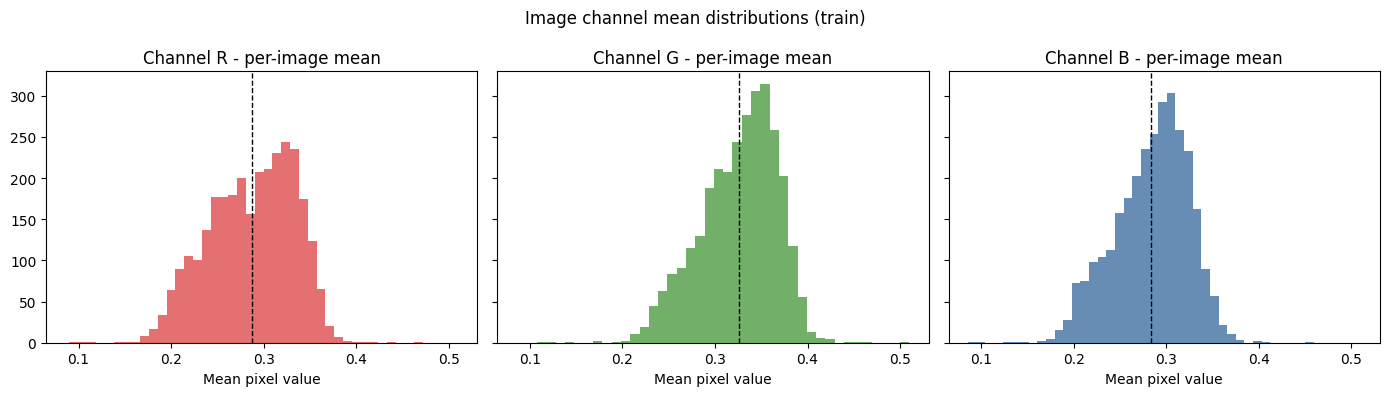

In [51]:
print("\n" + "=" * 70)
print("3. IMAGE STATISTICS")
print("=" * 70)

all_train_ids = split_ids["train"]
num_images = len(all_train_ids)
channel_means = np.zeros((num_images, 3), dtype=np.float64)
channel_stds = np.zeros((num_images, 3), dtype=np.float64)
global_min, global_max = np.inf, -np.inf

t0 = time.time()
for i, sid in enumerate(all_train_ids):
    img = load("train", "image", sid).astype(np.float64).squeeze()
    channel_means[i] = img.reshape(-1, 3).mean(axis=0)
    channel_stds[i] = img.reshape(-1, 3).std(axis=0)
    global_min = min(global_min, img.min())
    global_max = max(global_max, img.max())
print(f"  Scanned {num_images} train images in {time.time()-t0:.1f}s")

dataset_mean = channel_means.mean(axis=0)
dataset_std = channel_stds.mean(axis=0)

print(f"\n  Global pixel range: [{global_min:.4f}, {global_max:.4f}]")
print(f"  Per-channel mean (R,G,B): {dataset_mean}")
print(f"  Per-channel std  (R,G,B): {dataset_std}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True, sharex=True)
channel_colors = ["#e15759", "#59a14f", "#4e79a7"]
for i, (channel_name, color) in enumerate(zip(["R", "G", "B"], channel_colors)):
    axes[i].hist(channel_means[:, i], bins=40, color=color, edgecolor="none", alpha=0.85)
    axes[i].axvline(dataset_mean[i], color="k", ls="--", lw=1)
    axes[i].set_title(f"Channel {channel_name} - per-image mean")
    axes[i].set_xlabel("Mean pixel value")
plt.suptitle("Image channel mean distributions (train)", fontsize=12)
plt.tight_layout()
plt.show()

# 4. Inverse Depth Analysis


4. INVERSE DEPTH ANALYSIS
  Scanned 2975 train inverse depth maps in 1.7s

  Global inverse depth range: [0.000000, 0.492210]
  Percentiles:
      1th: 0.000000
      5th: 0.000000
     25th: 0.018280
     50th: 0.072251
     75th: 0.194614
     95th: 0.337179
     99th: 0.373816

  Zero-value (invalid) pixel ratio:
    Mean across images: 17.82%
    Min:  12.62%
    Max:  38.22%
    Median: 17.68%


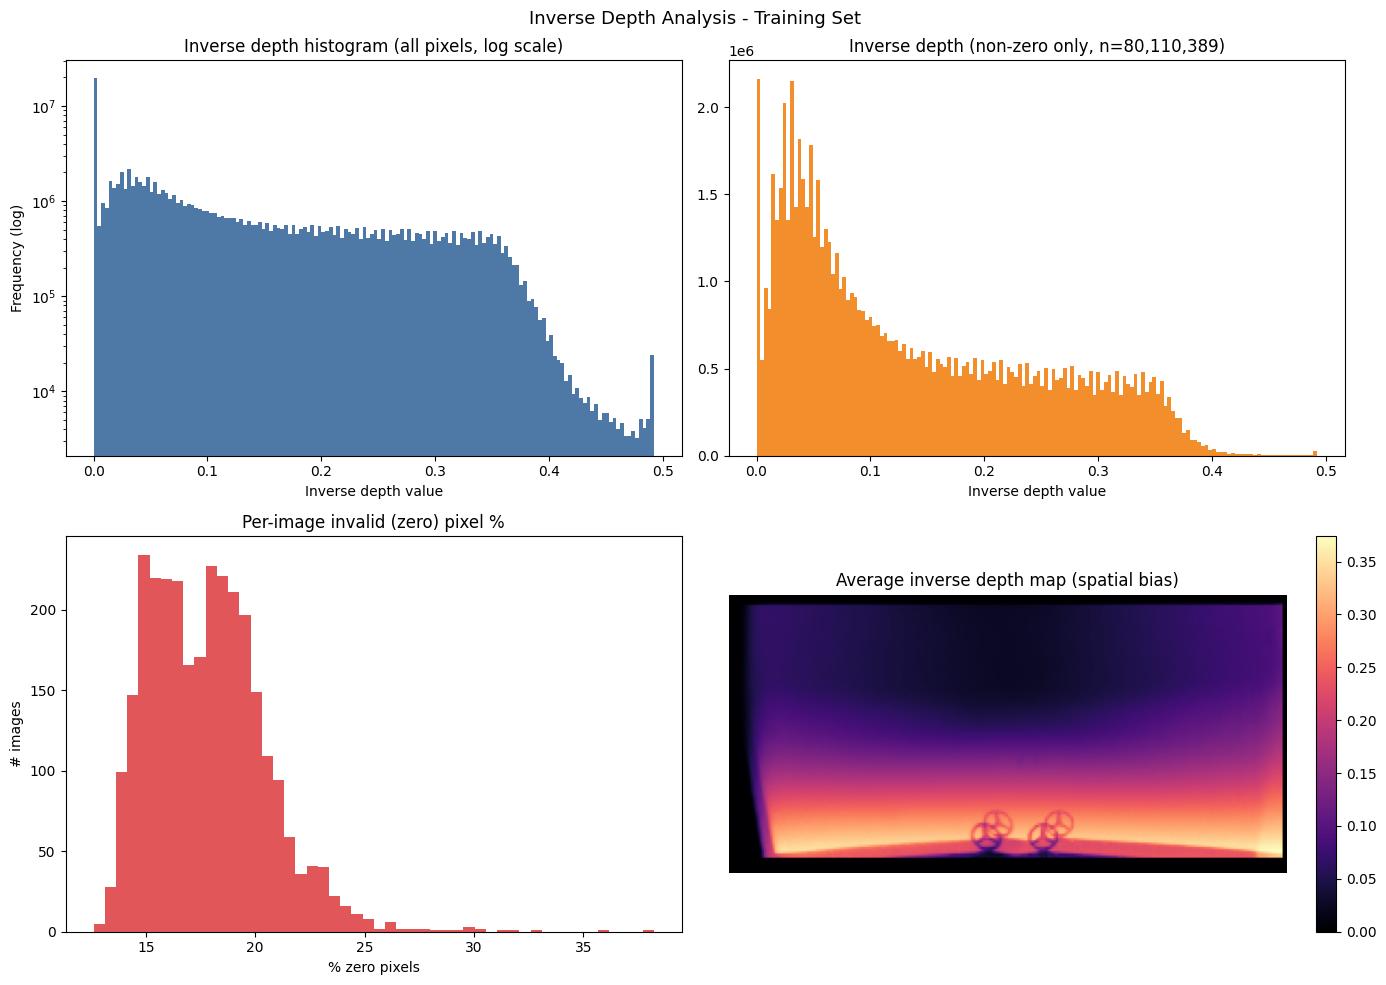

In [52]:
print("\n" + "=" * 70)
print("4. INVERSE DEPTH ANALYSIS")
print("=" * 70)

# Collect stats per image + accumulate for global histogram
depth_mins = np.zeros(num_images)
depth_maxs = np.zeros(num_images)
depth_means = np.zeros(num_images)
zero_ratios = np.zeros(num_images)
spatial_sum = np.zeros((128, 256), dtype=np.float64)
depth_pixels_all = []

t0 = time.time()
for i, sid in enumerate(all_train_ids):
    dep = load("train", "depth", sid).squeeze()
    depth_mins[i] = dep.min()
    depth_maxs[i] = dep.max()
    depth_means[i] = dep.mean()
    zero_ratios[i] = (dep == 0).mean()
    spatial_sum += dep
    depth_pixels_all.append(dep.ravel())

depth_pixels_all = np.concatenate(depth_pixels_all)
spatial_avg = spatial_sum / num_images
print(f"  Scanned {num_images} train inverse depth maps in {time.time()-t0:.1f}s")

# Percentiles
percentiles = [1, 5, 25, 50, 75, 95, 99]
percentile_values = np.percentile(depth_pixels_all, percentiles)
print(f"\n  Global inverse depth range: [{depth_pixels_all.min():.6f}, {depth_pixels_all.max():.6f}]")
print(f"  Percentiles:")
for p, v in zip(percentiles, percentile_values):
    print(f"    {p:3d}th: {v:.6f}")

# Invalid pixel stats
print(f"\n  Zero-value (invalid) pixel ratio:")
print(f"    Mean across images: {zero_ratios.mean()*100:.2f}%")
print(f"    Min:  {zero_ratios.min()*100:.2f}%")
print(f"    Max:  {zero_ratios.max()*100:.2f}%")
print(f"    Median: {np.median(zero_ratios)*100:.2f}%")

# Figure: inverse depth histogram + invalid ratio distribution + spatial heatmap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 4a: Full histogram
axes[0, 0].hist(depth_pixels_all, bins=150, color="#4e79a7", edgecolor="none", log=True)
axes[0, 0].set_title("Inverse depth histogram (all pixels, log scale)")
axes[0, 0].set_xlabel("Inverse depth value")
axes[0, 0].set_ylabel("Frequency (log)")

# 4b: Non-zero histogram
nonzero = depth_pixels_all[depth_pixels_all > 0]
axes[0, 1].hist(nonzero, bins=150, color="#f28e2b", edgecolor="none")
axes[0, 1].set_title(f"Inverse depth (non-zero only, n={len(nonzero):,})")
axes[0, 1].set_xlabel("Inverse depth value")

# 4c: Per-image zero ratio distribution
axes[1, 0].hist(zero_ratios * 100, bins=50, color="#e15759", edgecolor="none")
axes[1, 0].set_title("Per-image invalid (zero) pixel %")
axes[1, 0].set_xlabel("% zero pixels")
axes[1, 0].set_ylabel("# images")

# 4d: Spatial average inverse depth map
im = axes[1, 1].imshow(spatial_avg, cmap="magma")
axes[1, 1].set_title("Average inverse depth map (spatial bias)")
axes[1, 1].axis("off")
plt.colorbar(im, ax=axes[1, 1], fraction=0.046)

plt.suptitle("Inverse Depth Analysis - Training Set", fontsize=13)
plt.tight_layout()
plt.show()

# 5. Segmentation Analysis

- Is the segmentation data useful for depth estimation?
- Interpret the 0 inverse-distance

In [53]:
print("\n" + "=" * 70)
print("5. LIGHT SEGMENTATION CONTEXT")
print("=" * 70)

# Unique label values
all_label_values = set()
void_depth_class_counts = Counter()
total_void_depth_pixels = 0

t0 = time.time()
for sid in all_train_ids:
    lbl = load("train", "label", sid).squeeze().astype(int)
    dep = load("train", "depth", sid).squeeze()
    all_label_values.update(lbl.ravel().tolist())

    # Where inverse depth == 0, which labels appear?
    mask_zero_depth = dep == 0
    if mask_zero_depth.any():
        classes_at_zero = lbl[mask_zero_depth]
        for c in classes_at_zero.ravel():
            void_depth_class_counts[c] += 1
            total_void_depth_pixels += 1

print(f"  Scanned {num_images} train samples in {time.time()-t0:.1f}s")
print(f"  Unique label values: {sorted(all_label_values)}")
print(f"  Expected: -1 (void) + 0..18 (19 classes)")

if total_void_depth_pixels > 0:
    print(f"\n  Where inverse depth==0, which semantic classes appear?")
    print(f"  (Total zero-valued pixels: {total_void_depth_pixels:,})")
    for cls_id, cnt in void_depth_class_counts.most_common(10):
        pct = cnt / total_void_depth_pixels * 100
        name = CITYSCAPES_CLASSES[cls_id] if 0 <= cls_id < N_CLASSES else f"void({cls_id})"
        print(f"    {name:20s}: {pct:6.2f}%  ({cnt:,} px)")
else:
    print("  No zero-valued inverse depth pixels found.")


5. LIGHT SEGMENTATION CONTEXT
  Scanned 2975 train samples in 11.7s
  Unique label values: [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  Expected: -1 (void) + 0..18 (19 classes)

  Where inverse depth==0, which semantic classes appear?
  (Total zero-valued pixels: 17,374,411)
    void(-1)            :  44.27%  (7,691,125 px)
    road                :  18.18%  (3,158,391 px)
    building            :  12.79%  (2,222,383 px)
    vegetation          :   7.97%  (1,384,447 px)
    sky                 :   5.61%  (974,380 px)
    car                 :   4.64%  (806,777 px)
    sidewalk            :   2.86%  (497,370 px)
    terrain             :   0.66%  (114,788 px)
    pole                :   0.65%  (112,849 px)
    fence               :   0.56%  (97,243 px)


# 6. Conclusions

## Dataset Overview
- **Train:** 2 975 samples, **Val:** 500 samples (roughly 86/14 split)
- All files perfectly paired across modalities (image, depth, label)
- Uniform shape: image `(128, 256, 3)`, depth `(128, 256, 1)`, label `(128, 256)` - all `float64`

## Image Normalization
- Pixel values already in **[0, 1]** - no rescaling needed during loading
- **Per-channel mean (R, G, B):** `[0.2869, 0.3254, 0.2839]`
- **Per-channel std  (R, G, B):** `[0.1701, 0.1748, 0.1722]`

## Inverse Depth Target
- Values represent **inverse depth** (disparity), range `[0.0, 0.49]`
- **18% of pixels per image are zero (invalid)** - median 17.7%, worst case 38.2%
- Distribution is heavily right-skewed: most valid pixels have small inverse depth values (far objects dominate)
- The spatial average heatmap confirms strong structural bias: near-field (high values) at the bottom, far-field (low values) at the top, with vehicle artifacts visible at the bottom

## Invalid Pixel Analysis
- Zero-valued inverse depth pixels are **not** exclusively sky - they span void label (44%), road edges (18%), building (12%), vegetation (8%), sky (5%), car (5%)
- This means zero values encode both "infinite distance" (sky) and "no valid data" (occlusions, edges, sensor failures)
- **All zero-valued pixels must be masked in the loss function** - they are not meaningful inverse depth targets

## Resolution
- Uniform **128 x 256** - no resizing or padding needed
- Both dimensions are powers of 2, which is ideal for U-Net encoder/decoder skip connections

## Data Preprocessing and Training Plan

| Step | Idea |
|---|---|
| **Input normalization** | Standardize with dataset mean/std, or simply leave [0,1] as-is |
| **Loss function** | Masked L1 or masked MSE (ignore `inverse_depth == 0` pixels) |
| **Target transform** | Log-transform of non-zero inverse depth values to reduce skew |
| **Output activation** | Sigmoid (targets fit in [0.0, 0.5]) or linear with clamp |
| **Invalid mask** | `mask = (inverse_depth > 0)` applied to loss computation |
| **Data type** | Cast to `float32` or less during loading to save memory |